In [ ]:
import matplotlib.pyplot as plt
import asdf
import healpy as hp
import numpy as np
import pymaster as nmt
from tqdm import tqdm

import jax_cosmo.background as bkgrd
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance

cosmo_params = {'Om0': 0.3137, 'Ob0': 0.0493, 'H0': 67.36, 'sigma8': 0.8079, 'ns': 0.9649, 'w0': -1.0}
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )

z_array = np.linspace(0, 1.5, 200)
z_centers = 0.5 * (z_array[1:] + z_array[:-1])

nside = 4096
zedges_comoving = np.linspace(0, 1.5, 51)
zcens_comoving = 0.5*(zedges_comoving[1:] + zedges_comoving[:-1])

chi_edges_comoving = radial_comoving_distance(cosmo_jax, 1/(1 + zedges_comoving))
chi_min_comoving = chi_edges_comoving[:-1]
chi_max_comoving = chi_edges_comoving[1:]


for ji in range(1):
    print(ji)
    ldir = f'/mnt/ceph/users/spandey/abacus/AbacusSummit_base_c000_ph00{ji}'
    zvals = [[0.3, 0.35, 0.4], [0.45, 0.5, 0.575], [0.65, 0.725, 0.8]]

    fsky = (1/8.)

    comoving_volume_shells = fsky * (4.0/3.0) * np.pi * (chi_max_comoving**3 - chi_min_comoving**3)
    nbar_comoving = np.zeros_like(zcens_comoving) + 1e-8


    nz_gal_all = {}
    Cl_gg_all = {}
    nz_gal_all['z_array'] = z_centers

    Ngal_all = {}

    zmin_all = {}
    zmax_all = {}

    zedges_comoving = np.linspace(0, 1.5, 51)
    zcens_comoving = 0.5*(zedges_comoving[1:] + zedges_comoving[:-1])

    chi_edges_comoving = radial_comoving_distance(cosmo_jax, 1/(1 + zedges_comoving))
    chi_min_comoving = chi_edges_comoving[:-1]
    chi_max_comoving = chi_edges_comoving[1:]
    fsky = (1/8.)
    comoving_volume_shells = fsky * (4.0/3.0) * np.pi * (chi_max_comoving**3 - chi_min_comoving**3)

    nbar_comoving = np.zeros_like(zcens_comoving) + 1e-8

    for jz, zval_group in tqdm(enumerate(zvals)):
        gal_ra, gal_dec, gal_z = [], [], []
        rand_ra, rand_dec, rand_z = [], [], []
        for zval in tqdm(zval_group):
            
            fn = f"{ldir}/z{zval:.3f}/catalog_DESI_LRG.asdf"
            f = asdf.open(fn)

            gal_ra.extend(f['data']['RA'])
            gal_dec.extend(f['data']['DEC'])
            gal_z.extend(f['data']['Z_COSMO'])

            rand_ra.extend(f['data']['RAND_RA'])
            rand_dec.extend(f['data']['RAND_DEC'])
            rand_z.extend(f['data']['RAND_Z'])

        hist_z = np.histogram(gal_z, bins=z_array, density=True)[0]
        hist_z_rand = np.histogram(rand_z, bins=z_array, density=True)[0]

        zmin_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = np.min(gal_z)
        zmax_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = np.max(gal_z)


        for jzc in range(len(zcens_comoving)):
            indsel_jsz = np.where((gal_z >= zedges_comoving[jzc]) & (gal_z < zedges_comoving[jzc+1]))[0]
            nbar_comoving[jzc] += len(indsel_jsz)/comoving_volume_shells[jzc]

        nz_gal_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = hist_z
        Ngal_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = len(gal_z)

        ipix = hp.ang2pix(nside, gal_ra, gal_dec, lonlat=True)
        npix = hp.nside2npix(nside)

        nmap = np.bincount(ipix, minlength=npix)

        ipix_rand = hp.ang2pix(nside, rand_ra, rand_dec, lonlat=True)
        npix_rand = hp.nside2npix(nside)

        nmap_rand = np.bincount(ipix_rand, minlength=npix_rand)

        print('Running NaMaster for Cl_gg...')
        lmax = nside
        b = nmt.NmtBin.from_lmax_linear(lmax, nlb=200)
        leff = b.get_effective_ells()
        pos_data = np.array([f['data']['RA'], f['data']['DEC']])
        w_data = np.ones_like(f['data']['RA'])
        pos_ran = np.array([f['data']['RAND_RA'], f['data']['RAND_DEC']])
        w_ran = np.ones_like(f['data']['RAND_RA'])
        f_cat = nmt.NmtFieldCatalogClustering(pos_data, w_data, pos_ran, w_ran, lmax=lmax, lonlat=True)
        w_cat = nmt.NmtWorkspace.from_fields(f_cat, f_cat, b)
        pcl = nmt.compute_coupled_cell(f_cat, f_cat)
        cl_cat = w_cat.decouple_cell(pcl)

        Cl_gg_all['l_array'] = leff
        Cl_gg_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = cl_cat[0]

    for jz, zval_group in tqdm(enumerate(zvals)):
        gal_ra, gal_dec, gal_z = [], [], []
        for zval in tqdm(zval_group):
            
            fn = f"{ldir}/z{zval:.3f}/catalog_DESI_LRG.asdf"
            f = asdf.open(fn)

            gal_ra.extend(f['data']['RA'])
            gal_dec.extend(f['data']['DEC'])
            gal_z.extend(f['data']['Z_COSMO'])

        for jzc in range(len(zcens_comoving)):
            indsel_jsz = np.where((gal_z >= zedges_comoving[jzc]) & (gal_z < zedges_comoving[jzc+1]))[0]
            nbar_comoving[jzc] += len(indsel_jsz)/comoving_volume_shells[jzc]


    import pickle as pk
    with open(f'/mnt/ceph/users/spandey/abacus/abacus_LRG_nz_Clgg_v4_AbacusSummit_base_c000_ph00{ji}.pkl', 'wb') as f:
        pk.dump({'nz_gal_all': nz_gal_all, 'Cl_gg_all': Cl_gg_all,'Ngal_all':Ngal_all,  
                'nbar_comoving': nbar_comoving, 'zcens_comoving': zcens_comoving,
                'zmin_all': zmin_all, 'zmax_all': zmax_all, 'zvals': zvals}, f)






/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:121: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


0


100%|██████████| 3/3 [00:43<00:00, 14.44s/it]


Running NaMaster for Cl_gg...


 33%|███▎      | 1/3 [00:39<01:18, 39.37s/it]
1it [01:48, 108.61s/it]


KeyboardInterrupt: 

/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:121: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


0


100%|██████████| 3/3 [03:01<00:00, 60.39s/it]
3it [07:29, 149.83s/it]
100%|██████████| 3/3 [00:11<00:00,  3.77s/it]
3it [00:32, 10.73s/it]
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:121: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


1


100%|██████████| 3/3 [03:02<00:00, 60.96s/it]
3it [07:30, 150.05s/it]
100%|██████████| 3/3 [00:11<00:00,  3.80s/it]
3it [00:33, 11.03s/it]


...

100%|██████████| 3/3 [03:01<00:00, 60.53s/it]
3it [07:28, 149.65s/it]
100%|██████████| 3/3 [00:10<00:00,  3.46s/it]
3it [00:32, 10.81s/it]


6


100%|██████████| 3/3 [03:02<00:00, 60.82s/it]
3it [07:31, 150.64s/it]
100%|██████████| 3/3 [00:11<00:00,  3.74s/it]
3it [00:33, 11.15s/it]


7


100%|██████████| 3/3 [03:01<00:00, 60.39s/it]
3it [07:32, 150.88s/it]
100%|██████████| 3/3 [00:11<00:00,  4.00s/it]
3it [00:34, 11.35s/it]


In [1]:
import matplotlib.pyplot as plt
import asdf
import healpy as hp
import numpy as np
import pymaster as nmt
from tqdm import tqdm
import jax.numpy as jnp
import jax_cosmo.background as bkgrd
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
import jax.numpy as jnp
import pickle as pk
%matplotlib inline


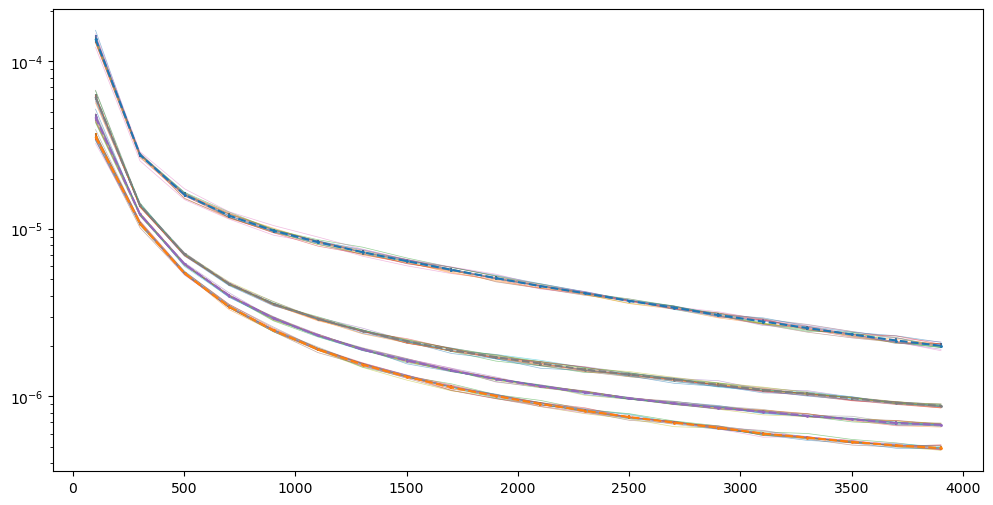

In [2]:
Cl_gg_sims0_all = []
Cl_gg_sims1_all = []
Cl_gg_sims2_all = []
Cl_gg_sims3_all = []
Ngal_z0_all = []
Ngal_z1_all = []
Ngal_z2_all = []
Ngal_z3_all = []

nsims = 16
ldir = '/mnt/ceph/users/spandey/abacus'
for ji in range(nsims):
    try:
        # if ji == 0:
        # df_sims = pk.load(open(f'{ldir}/abacus_LRG_nz_Clgg_v4_deltaell_100_AbacusSummit_base_c000_ph00{ji}.pkl','rb'))
        df_sims = pk.load(open(f'{ldir}/abacus_LRG_nz_Clgg_v5_deltaell_200_AbacusSummit_base_c000_ph00{ji}.pkl','rb'))        
        Cls_sims = df_sims['Cl_gg_all']
        l_array_sims = jnp.array(Cls_sims['l_array'])
        Cl_gg_sims0 = jnp.array(Cls_sims['z0.300_0.400'])
        Cl_gg_sims1 = jnp.array(Cls_sims['z0.450_0.575'])
        Cl_gg_sims2 = jnp.array(Cls_sims['z0.650_0.800'])
        Cl_gg_sims3 = jnp.array(Cls_sims['z0.875_1.100'])
        Cl_gg_sims0_all.append(Cl_gg_sims0)
        Cl_gg_sims1_all.append(Cl_gg_sims1)
        Cl_gg_sims2_all.append(Cl_gg_sims2)
        Cl_gg_sims3_all.append(Cl_gg_sims3)

        Ngal_z0_all.append(df_sims['Ngal_all']['z0.300_0.400'])
        Ngal_z1_all.append(df_sims['Ngal_all']['z0.450_0.575'])
        Ngal_z2_all.append(df_sims['Ngal_all']['z0.650_0.800'])
        Ngal_z3_all.append(df_sims['Ngal_all']['z0.875_1.100'])
    except Exception as e:
        print(f"Error processing simulation {ji}: {e}")
        pass
    


Ngal_all_final = {}
Ngal_all_final['z0.300_0.400'] = np.sum(np.array(Ngal_z0_all), axis=0)
Ngal_all_final['z0.450_0.575'] = np.sum(np.array(Ngal_z1_all), axis=0)
Ngal_all_final['z0.650_0.800'] = np.sum(np.array(Ngal_z2_all), axis=0)
Ngal_all_final['z0.875_1.100'] = np.sum(np.array(Ngal_z3_all), axis=0)

Cl_gg_sims0 = jnp.mean(jnp.array(Cl_gg_sims0_all), axis=0)
Cl_gg_sims1 = jnp.mean(jnp.array(Cl_gg_sims1_all), axis=0)
Cl_gg_sims2 = jnp.mean(jnp.array(Cl_gg_sims2_all), axis=0)
Cl_gg_sims3 = jnp.mean(jnp.array(Cl_gg_sims3_all), axis=0)

Cl_gg_sims0_std = jnp.std(jnp.array(Cl_gg_sims0_all), axis=0)
Cl_gg_sims1_std = jnp.std(jnp.array(Cl_gg_sims1_all), axis=0)
Cl_gg_sims2_std = jnp.std(jnp.array(Cl_gg_sims2_all), axis=0)
Cl_gg_sims3_std = jnp.std(jnp.array(Cl_gg_sims3_all), axis=0)

Cls_sims_final = {}
Cls_sims_final['l_array'] = l_array_sims
Cls_sims_final['z0.300_0.400'] = Cl_gg_sims0
Cls_sims_final['z0.450_0.575'] = Cl_gg_sims1
Cls_sims_final['z0.650_0.800'] = Cl_gg_sims2
Cls_sims_final['z0.875_1.100'] = Cl_gg_sims3

Cl_std_sims_final = {}
Cl_std_sims_final['z0.300_0.400'] = Cl_gg_sims0_std
Cl_std_sims_final['z0.450_0.575'] = Cl_gg_sims1_std
Cl_std_sims_final['z0.650_0.800'] = Cl_gg_sims2_std
Cl_std_sims_final['z0.875_1.100'] = Cl_gg_sims3_std

plt.figure(figsize=(12,6))
plt.errorbar(l_array_sims, Cl_gg_sims0, yerr=Cl_gg_sims0_std, ls='--', marker='o', markersize=1)
for ji in range(len(Cl_gg_sims0_all)):
    plt.plot(l_array_sims, Cl_gg_sims0_all[ji], lw=0.5, alpha=0.5)

plt.errorbar(l_array_sims, Cl_gg_sims1, yerr=Cl_gg_sims1_std, ls='--', marker='o', markersize=1)
for ji in range(len(Cl_gg_sims1_all)):
    plt.plot(l_array_sims, Cl_gg_sims1_all[ji], lw=0.5, alpha=0.5)

plt.errorbar(l_array_sims, Cl_gg_sims2, yerr=Cl_gg_sims2_std, ls='--', marker='o', markersize=1)
for ji in range(len(Cl_gg_sims2_all)):
    plt.plot(l_array_sims, Cl_gg_sims2_all[ji], lw=0.5, alpha=0.5)

plt.errorbar(l_array_sims, Cl_gg_sims3, yerr=Cl_gg_sims3_std, ls='--', marker='o', markersize=1)
for ji in range(len(Cl_gg_sims3_all)):
    plt.plot(l_array_sims, Cl_gg_sims3_all[ji], lw=0.5, alpha=0.5)
# plt.xscale('log')
plt.yscale('log')
# plt.xlim(1000,4000)
# plt.ylim(5e-7, 5e-6)
plt.show()   




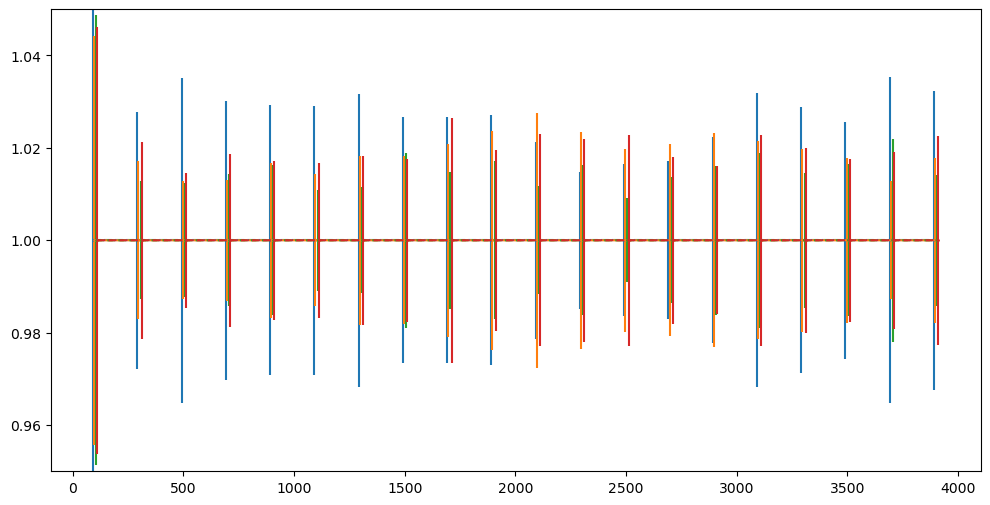

In [3]:
plt.figure(figsize=(12,6))
plt.errorbar(l_array_sims-10, Cl_gg_sims0/Cl_gg_sims0, yerr=Cl_gg_sims0_std/Cl_gg_sims0, ls='--', marker='o', markersize=1)
plt.errorbar(l_array_sims-5, Cl_gg_sims1/Cl_gg_sims1, yerr=Cl_gg_sims1_std/Cl_gg_sims1, ls='--', marker='o', markersize=1)
plt.errorbar(l_array_sims+5, Cl_gg_sims2/Cl_gg_sims2, yerr=Cl_gg_sims2_std/Cl_gg_sims2, ls='--', marker='o', markersize=1)
plt.errorbar(l_array_sims+10, Cl_gg_sims3/Cl_gg_sims3, yerr=Cl_gg_sims3_std/Cl_gg_sims3, ls='--', marker='o', markersize=1)

# for ji in range(len(Cl_gg_sims2_all)):
#     plt.plot(l_array_sims, Cl_gg_sims2_all[ji], lw=0.5, alpha=0.5)
# plt.xscale('log')
# plt.yscale('log')
# plt.xlim(1000,4000)
# plt.ylim(5e-7, 5e-6)
plt.ylim(0.95, 1.05) 
plt.show() 
 

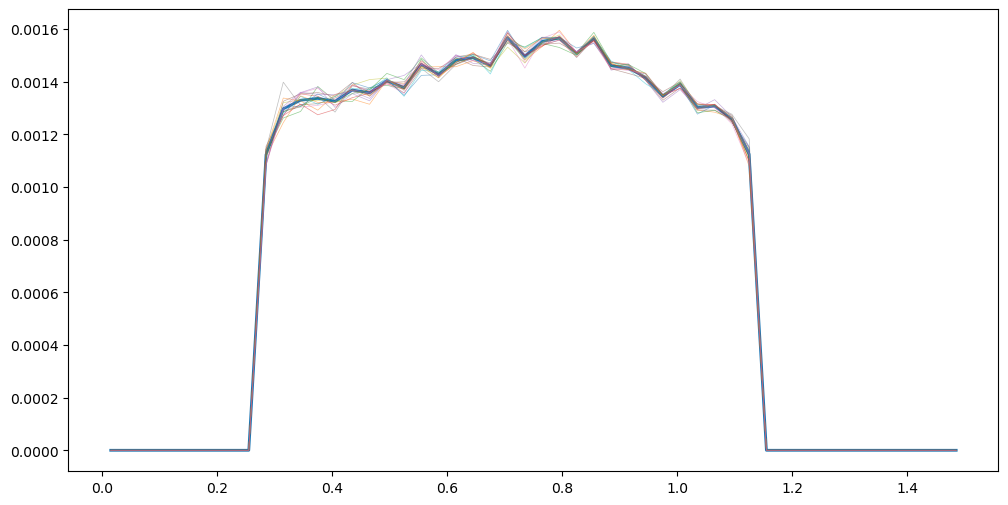

In [4]:
nbar_comoving_all = []
# nsims = 6
ldir = '/mnt/ceph/users/spandey/abacus'
for ji in range(nsims):
    try:
        df_sims = pk.load(open(f'{ldir}/abacus_LRG_nz_Clgg_v5_deltaell_200_AbacusSummit_base_c000_ph00{ji}.pkl','rb'))
        nbar_comoving_all.append(df_sims['nbar_comoving'])
        zcens_comoving = df_sims['zcens_comoving']
    except Exception as e:
        print(f"Error processing simulation {ji}: {e}")
        pass
nbar_comoving = jnp.mean(jnp.array(nbar_comoving_all), axis=0)

plt.figure(figsize=(12,6))
plt.plot(zcens_comoving, nbar_comoving, lw=2.0)
for ji in range(len(nbar_comoving_all)):
    plt.plot(zcens_comoving, nbar_comoving_all[ji], lw=0.5, alpha=0.5)
    


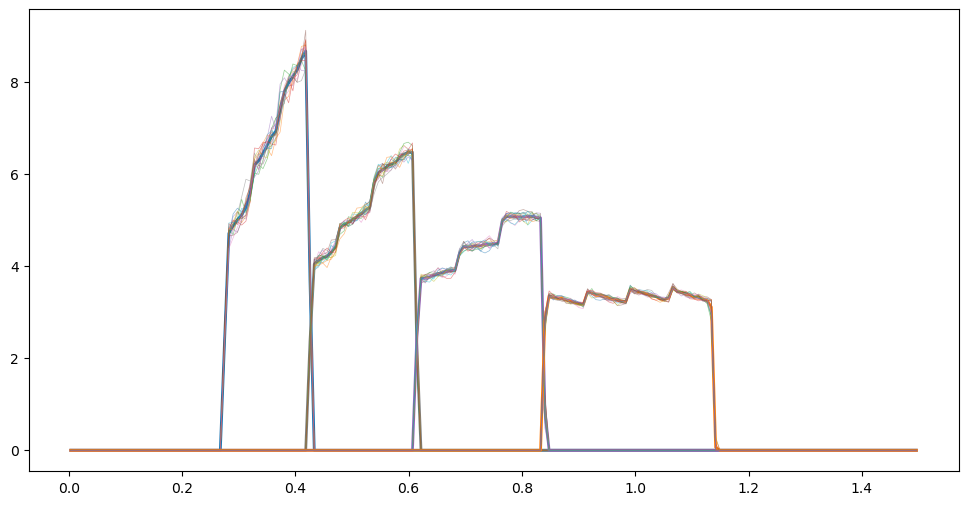

In [5]:
nz_z0_all = []
nz_z1_all = []
nz_z2_all = []
nz_z3_all = []
# nsims = 6
ldir = '/mnt/ceph/users/spandey/abacus'
for ji in range(nsims):
    try:
        df_sims = pk.load(open(f'{ldir}/abacus_LRG_nz_Clgg_v5_deltaell_200_AbacusSummit_base_c000_ph00{ji}.pkl','rb'))
        # print(df_sims['nz_gal_all'].keys())
        nz_sims = df_sims['nz_gal_all']
        z_array_sims = jnp.array(nz_sims['z_array'])
        nz_z0 = jnp.array(nz_sims['z0.300_0.400'])
        nz_z1 = jnp.array(nz_sims['z0.450_0.575'])
        nz_z2 = jnp.array(nz_sims['z0.650_0.800'])
        nz_z3 = jnp.array(nz_sims['z0.875_1.100'])
        nz_z0_all.append(nz_z0)
        nz_z1_all.append(nz_z1)
        nz_z2_all.append(nz_z2)
        nz_z3_all.append(nz_z3)
    except Exception as e:
        print(f"Error processing simulation {ji}: {e}")
        pass

nz_z0 = jnp.mean(jnp.array(nz_z0_all), axis=0)
nz_z1 = jnp.mean(jnp.array(nz_z1_all), axis=0)
nz_z2 = jnp.mean(jnp.array(nz_z2_all), axis=0)
nz_z3 = jnp.mean(jnp.array(nz_z3_all), axis=0)

nz_sims_final = {}
nz_sims_final['z_array'] = z_array_sims
nz_sims_final['z0.300_0.400'] = nz_z0
nz_sims_final['z0.450_0.575'] = nz_z1
nz_sims_final['z0.650_0.800'] = nz_z2
nz_sims_final['z0.875_1.100'] = nz_z3

plt.figure(figsize=(12,6))
plt.plot(z_array_sims, nz_z0, lw=2.0)
for ji in range(len(nz_z0_all)):
    plt.plot(z_array_sims, nz_z0_all[ji], lw=0.5, alpha=0.5)
plt.plot(z_array_sims, nz_z1, lw=2.0)
for ji in range(len(nz_z1_all)):
    plt.plot(z_array_sims, nz_z1_all[ji], lw=0.5, alpha=0.5)
plt.plot(z_array_sims, nz_z2, lw=2.0)
for ji in range(len(nz_z2_all)):
    plt.plot(z_array_sims, nz_z2_all[ji], lw=0.5, alpha=0.5)
plt.plot(z_array_sims, nz_z3, lw=2.0)
for ji in range(len(nz_z3_all)):
    plt.plot(z_array_sims, nz_z3_all[ji], lw=0.5, alpha=0.5)
    

In [6]:
# len(nz_z0_all)


In [7]:
saved_final = {}
saved_final['Cl_gg_all'] = Cls_sims_final
saved_final['Cl_gg_all_std'] = Cl_std_sims_final
saved_final['Ngal_all'] = Ngal_all_final
saved_final['nz_gal_all'] = nz_sims_final
saved_final['nbar_comoving'] = nbar_comoving
saved_final['zcens_comoving'] = zcens_comoving
saved_final['zvals'] = df_sims['zvals']
saved_final['zmin_all'] = df_sims['zmin_all']
saved_final['zmax_all'] = df_sims['zmax_all']
with open(f'{ldir}/abacus_LRG_nz_Clgg_v5_deltaell_200_combined_{len(nz_z0_all)}sims.pkl', 'wb') as f:
    pk.dump(saved_final, f)



In [8]:
ldir


'/mnt/ceph/users/spandey/abacus'

In [17]:
from scipy import interpolate
def interpolate_cl(field1, field2, nmt_bin_width, ell_interpol_max):
    # Define new binning (has to be in C_ell)
    # b = nmt.NmtBin.from_lmax_linear(ell_interpol_max+100, nmt_bin_width, is_Dell=False)
    b = nmt.NmtBin.from_lmax_linear(ell_interpol_max, nmt_bin_width)
    ell= b.get_effective_ells()

    # #Compute new Cl's cl_inter to interpolate
    cl = nmt.compute_full_master(field1, field2, b)

    #set cl(ell=1) to zero to avoid extrapolation
    cl2 = np.insert(cl,[0,0],[0,0] )
    ell2 = np.insert(ell,[0,0],[0,1])

    #interpolate
    ell_new=np.arange(0., ell_interpol_max, 1) #up to ell_interp_max
    f=interpolate.interp1d(np.log(ell2), np.log(cl2), fill_value="extrapolate")
    cl_interpolate=np.exp(f(np.log(ell_new)))

    return cl_interpolate, ell_new

    

/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:121: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


0


0it [00:00, ?it/s]

100%|██████████| 3/3 [00:37<00:00, 12.58s/it]


Namaster bins: [ 51.5 151.5 251.5 351.5 451.5]
Computing Cl_gg...
Done computing Cl_gg.


/tmp/ipykernel_383359/181578787.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', ncol=2, labelspacing=0.1)


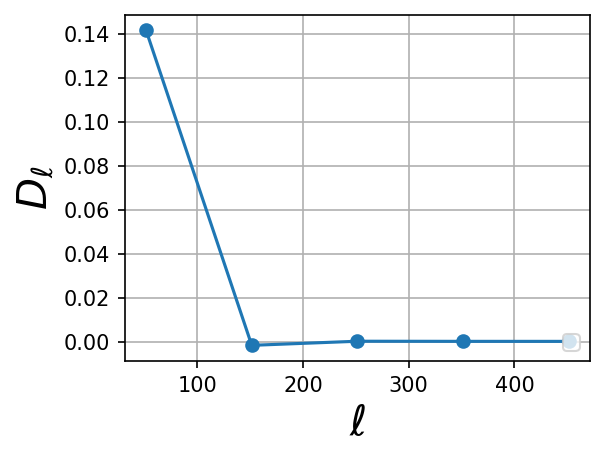

0it [00:41, ?it/s]

Preparing interpolation of Cl...


ValueError: Maximum multipoles in bins (622) and fields (512) are not the same.

In [ ]:
import matplotlib.pyplot as plt
z_array = np.linspace(0, 1.5, 200)
z_centers = 0.5 * (z_array[1:] + z_array[:-1])

# nside = 2048
nside = 256
zedges_comoving = np.linspace(0, 1.5, 51)
zcens_comoving = 0.5*(zedges_comoving[1:] + zedges_comoving[:-1])

chi_edges_comoving = radial_comoving_distance(cosmo_jax, 1/(1 + zedges_comoving))
chi_min_comoving = chi_edges_comoving[:-1]
chi_max_comoving = chi_edges_comoving[1:]


# for ji in range(1):
ji = 0
zvals = [[0.3, 0.35, 0.4]]


print(ji)
ldir = f'/mnt/ceph/users/spandey/abacus/AbacusSummit_base_c000_ph00{ji}'
# zvals = [[0.3, 0.35, 0.4], [0.45, 0.5, 0.575], [0.65, 0.725, 0.8]]

fsky = (1/8.)

comoving_volume_shells = fsky * (4.0/3.0) * np.pi * (chi_max_comoving**3 - chi_min_comoving**3)
nbar_comoving = np.zeros_like(zcens_comoving) + 1e-8


nz_gal_all = {}
Cl_gg_all = {}
nz_gal_all['z_array'] = z_centers

Ngal_all = {}

zmin_all = {}
zmax_all = {}

zedges_comoving = np.linspace(0, 1.5, 51)
zcens_comoving = 0.5*(zedges_comoving[1:] + zedges_comoving[:-1])

chi_edges_comoving = radial_comoving_distance(cosmo_jax, 1/(1 + zedges_comoving))
chi_min_comoving = chi_edges_comoving[:-1]
chi_max_comoving = chi_edges_comoving[1:]
fsky = (1/8.)
comoving_volume_shells = fsky * (4.0/3.0) * np.pi * (chi_max_comoving**3 - chi_min_comoving**3)

nbar_comoving = np.zeros_like(zcens_comoving) + 1e-8

for jz, zval_group in tqdm(enumerate(zvals)):
    gal_ra, gal_dec, gal_z = [], [], []
    rand_ra, rand_dec, rand_z = [], [], []
    for zval in tqdm(zval_group):
        
        fn = f"{ldir}/z{zval:.3f}/catalog_DESI_LRG.asdf"
        f = asdf.open(fn)

        gal_ra.extend(f['data']['RA'])
        gal_dec.extend(f['data']['DEC'])
        gal_z.extend(f['data']['Z_COSMO'])

        rand_ra.extend(f['data']['RAND_RA'])
        rand_dec.extend(f['data']['RAND_DEC'])
        rand_z.extend(f['data']['RAND_Z'])

    hist_z = np.histogram(gal_z, bins=z_array, density=True)[0]
    hist_z_rand = np.histogram(rand_z, bins=z_array, density=True)[0]

    zmin_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = np.min(gal_z)
    zmax_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = np.max(gal_z)


    for jzc in range(len(zcens_comoving)):
        indsel_jsz = np.where((gal_z >= zedges_comoving[jzc]) & (gal_z < zedges_comoving[jzc+1]))[0]
        nbar_comoving[jzc] += len(indsel_jsz)/comoving_volume_shells[jzc]

    nz_gal_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = hist_z
    Ngal_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = len(gal_z)

    ipix = hp.ang2pix(nside, gal_ra, gal_dec, lonlat=True)
    npix = hp.nside2npix(nside)

    nmap = np.bincount(ipix, minlength=npix)

    ipix_rand = hp.ang2pix(nside, rand_ra, rand_dec, lonlat=True)
    npix_rand = hp.nside2npix(nside)

    nmap_rand = np.bincount(ipix_rand, minlength=npix_rand)

    nside_mask_ds = 256
    ipix_mask = hp.ang2pix(nside_mask_ds, rand_ra, rand_dec, lonlat=True)
    npix_mask = hp.nside2npix(nside_mask_ds)
    nmap_mask = np.bincount(ipix_mask, minlength=npix_mask)
    nmap_mask = (nmap_mask > 0).astype(float)
    nmap_mask = hp.ud_grade(nmap_mask, nside)

    # ellmin = 100 
    ellmax = 2*nside+1
    binwidth= 100

    f_gal = nmt.NmtField(nmap_mask, [nmap], lmax=ellmax)

    # ell_ini = np.arange(ellmin+1, ellmax+1, binwidth)
    # ell_end = np.arange(ellmin+binwidth, ellmax+binwidth, binwidth)
    # print(ell_ini)
    # print(ell_end)

    # Initialize Namaster binning and get the central ells
    bins = nmt.NmtBin.from_lmax_linear(ellmax-1, nlb=binwidth)
    ell_nmt= bins.get_effective_ells()
    print("Namaster bins:", ell_nmt)

    print("Computing Cl_gg...")
    dl_gg = nmt.compute_full_master(f_gal, f_gal, bins)
    print("Done computing Cl_gg.")
    plt.subplots(figsize=(4, 3), dpi=150)
    plt.plot(ell_nmt, dl_gg[0], "-o")
    plt.yscale('log')
    plt.xlabel(r'$\ell$', fontsize=20)
    plt.ylabel(r'$D_{\ell}$', fontsize=20)
    plt.legend(loc='lower right', ncol=2, labelspacing=0.1)
    plt.grid()
    plt.show()

    print("Preparing interpolation of Cl...")
    interp_bin_width =10
    ELLMAX = ellmax+interp_bin_width #interpolate to larger ellmax than the measured cross-correlation
    cl_11, ell_inter = interpolate_cl(f_gal, f_gal, nmt_bin_width=interp_bin_width, ell_interpol_max=ELLMAX)


    print("Computing coupling matrix...")
    w = nmt.NmtWorkspace()
    w.compute_coupling_matrix(f_gal, f_gal, bins)

    # Gaussian estimate of the covariance
    print("Computing coupling coefficients...")
    cw = nmt.NmtCovarianceWorkspace()
    cw.compute_coupling_coefficients(f_gal, f_gal, f_gal, f_gal, lmax=ELLMAX-1) # lmax needs to be < len(cl1_interpolate)

    # Compute the covariance
    print("Computing covariance matrix...")
    n_bins=len(ell_nmt) # number of bins
    covar = nmt.gaussian_covariance(cw, 0, 0, 0, 0, [cl_11],[cl_11],[cl_11], [cl_11], w, wb=w).reshape([n_bins, 1,n_bins, 1])
    covariance = covar[:, 0, :, 0]

    # Get the errorbars
    sigma=np.sqrt(covariance.diagonal())

    plt.subplots(figsize=(4, 3), dpi=150)
    plt.errorbar(ell_nmt, dl_gg[0], sigma,  fmt ="o-", color="blue", label='Clgg')
    plt.xlabel(r'$\ell$', fontsize=20)
    plt.ylabel(r'$D_{\ell}$', fontsize=20)
    plt.legend(loc='upper left', ncol=1, labelspacing=0.1, fontsize=9)
    plt.grid()
    plt.show()

#     lmax = 2*nside
#     b = nmt.NmtBin.from_lmax_linear(lmax, nlb=100)
#     leff = b.get_effective_ells()
#     pos_data = np.array([f['data']['RA'], f['data']['DEC']])
#     w_data = np.ones_like(f['data']['RA'])
#     pos_ran = np.array([f['data']['RAND_RA'], f['data']['RAND_DEC']])
#     w_ran = np.ones_like(f['data']['RAND_RA'])
#     f_cat = nmt.NmtFieldCatalogClustering(pos_data, w_data, pos_ran, w_ran, lmax=lmax, lonlat=True)
#     w_cat = nmt.NmtWorkspace.from_fields(f_cat, f_cat, b)
#     pcl = nmt.compute_coupled_cell(f_cat, f_cat)
#     cl_cat = w_cat.decouple_cell(pcl)

#     Cl_gg_all['l_array'] = leff
#     Cl_gg_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'] = cl_cat[0]

# for jz, zval_group in tqdm(enumerate(zvals)):
#     gal_ra, gal_dec, gal_z = [], [], []
#     for zval in tqdm(zval_group):
        
#         fn = f"{ldir}/z{zval:.3f}/catalog_DESI_LRG.asdf"
#         f = asdf.open(fn)

#         gal_ra.extend(f['data']['RA'])
#         gal_dec.extend(f['data']['DEC'])
#         gal_z.extend(f['data']['Z_COSMO'])

#     for jzc in range(len(zcens_comoving)):
#         indsel_jsz = np.where((gal_z >= zedges_comoving[jzc]) & (gal_z < zedges_comoving[jzc+1]))[0]
#         nbar_comoving[jzc] += len(indsel_jsz)/comoving_volume_shells[jzc]


# import pickle as pk
# with open(f'/mnt/ceph/users/spandey/abacus/abacus_LRG_nz_Clgg_v3_AbacusSummit_base_c000_ph00{ji}.pkl', 'wb') as f:
#     pk.dump({'nz_gal_all': nz_gal_all, 'Cl_gg_all': Cl_gg_all,'Ngal_all':Ngal_all,  
#             'nbar_comoving': nbar_comoving, 'zcens_comoving': zcens_comoving,
#             'zmin_all': zmin_all, 'zmax_all': zmax_all, 'zvals': zvals}, f)



In [25]:
from scipy import interpolate
def interpolate_cl(field1, field2, nmt_bin_width, ell_interpol_max):
    # Define new binning (has to be in C_ell)
    # b = nmt.NmtBin.from_lmax_linear(ell_interpol_max+100, nmt_bin_width, is_Dell=False)
    b = nmt.NmtBin.from_lmax_linear(ell_interpol_max, nmt_bin_width)
    ell= b.get_effective_ells()

    # #Compute new Cl's cl_inter to interpolate
    cl = nmt.compute_full_master(field1, field2, b)

    #set cl(ell=1) to zero to avoid extrapolation
    cl2 = np.insert(cl,[0,0],[0,0] )
    ell2 = np.insert(ell,[0,0],[0,1])

    #interpolate
    ell_new=np.arange(0., ell_interpol_max+1, 1) #up to ell_interp_max
    f=interpolate.interp1d(np.log(ell2), np.log(cl2), fill_value="extrapolate")
    cl_interpolate=np.exp(f(np.log(ell_new)))

    return cl_interpolate, ell_new


In [26]:
len(cl_11)

513

In [32]:
print("Preparing interpolation of Cl...")
ellmax = 3*nside - 10
interp_bin_width =10
ELLMAX = ellmax+1 #interpolate to larger ellmax than the measured cross-correlation
f_gal = nmt.NmtField(nmap_mask, [nmap], lmax=ELLMAX)
bins = nmt.NmtBin.from_lmax_linear(ELLMAX, nlb=binwidth)
cl_11, ell_inter = interpolate_cl(f_gal, f_gal, nmt_bin_width=interp_bin_width, ell_interpol_max=ELLMAX)

Cl_gg = nmt.compute_full_master(f_gal, f_gal, bins)

print("Computing coupling matrix...")
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f_gal, f_gal, bins)

# Gaussian estimate of the covariance
print("Computing coupling coefficients...")
cw = nmt.NmtCovarianceWorkspace()
cw.compute_coupling_coefficients(f_gal, f_gal, f_gal, f_gal, spin0_only=True) # lmax needs to be < len(cl1_interpolate)

# Compute the covariance
print("Computing covariance matrix...")
# n_bins=len(ell_nmt) # number of bins
n_bins=len(Cl_gg) # number of bins
covar = nmt.gaussian_covariance(cw, 0, 0, 0, 0, [cl_11],[cl_11],[cl_11], [cl_11], w, wb=w).reshape([n_bins, 1,n_bins, 1])
covariance = covar[:, 0, :, 0]

# Get the errorbars
sigma=np.sqrt(covariance.diagonal())

plt.subplots(figsize=(4, 3), dpi=150)
plt.errorbar(ell_nmt, dl_gg[0], sigma,  fmt ="o-", color="blue", label='Clgg')
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$D_{\ell}$', fontsize=20)
plt.legend(loc='upper left', ncol=1, labelspacing=0.1, fontsize=9)
plt.grid()
plt.show()




: 

In [30]:
Cl_gg


array([[ 0.14165484, -0.00165544,  0.00021052,  0.00015408,  0.00014263]])

In [ ]:
ellmin = 100 
ellmax = 2*nside
binwidth= 100


f_gal = nmt.NmtField(nmap_mask, [nmap], lmax=ellmax)

# ell_ini = np.arange(ellmin+1, ellmax+1, binwidth)
# ell_end = np.arange(ellmin+binwidth, ellmax+binwidth, binwidth)
# print(ell_ini)
# print(ell_end)

# Initialize Namaster binning and get the central ells
# bins=nmt.NmtBin.from_edges(ell_ini=ell_ini, ell_end=ell_end, is_Dell=False) #request the Namaster output as D_ell=ell*(ell+1)*C_ell/2pi
bins = nmt.NmtBin.from_lmax_linear(ellmax, nlb=binwidth)
ell_nmt= bins.get_effective_ells()
print("Namaster bins:", ell_nmt)

print("Computing Cl_gg...")
dl_gg = nmt.compute_full_master(f_gal, f_gal, bins)


Namaster bins: [ 51.5 151.5 251.5 351.5 451.5]
Computing Cl_gg...


In [10]:
zedges_comoving = np.linspace(0, 1.5, 51)
zcens_comoving = 0.5*(zedges_comoving[1:] + zedges_comoving[:-1])

chi_edges_comoving = radial_comoving_distance(cosmo_jax, 1/(1 + zedges_comoving))
chi_min_comoving = chi_edges_comoving[:-1]
chi_max_comoving = chi_edges_comoving[1:]

fsky = (1/8.)

comoving_volume_shells = fsky * (4.0/3.0) * np.pi * (chi_max_comoving**3 - chi_min_comoving**3)
ldir = '/mnt/ceph/users/spandey/abacus/AbacusSummit_base_c000_ph006'
nbar_comoving = np.zeros_like(zcens_comoving) + 1e-8
zvals = [[0.3, 0.35, 0.4], [0.45, 0.5, 0.575], [0.65, 0.725, 0.8]]
for jz, zval_group in tqdm(enumerate(zvals)):
    gal_ra, gal_dec, gal_z = [], [], []
    for zval in tqdm(zval_group):
        
        fn = f"{ldir}/z{zval:.3f}/catalog_DESI_LRG.asdf"
        f = asdf.open(fn)

        gal_ra.extend(f['data']['RA'])
        gal_dec.extend(f['data']['DEC'])
        gal_z.extend(f['data']['Z_COSMO'])

    for jzc in range(len(zcens_comoving)):
        indsel_jsz = np.where((gal_z >= zedges_comoving[jzc]) & (gal_z < zedges_comoving[jzc+1]))[0]
        nbar_comoving[jzc] += len(indsel_jsz)/comoving_volume_shells[jzc]

    
            

/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:121: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
0it [00:00, ?it/s]

100%|██████████| 3/3 [00:09<00:00,  3.05s/it]
3it [00:27,  9.26s/it]


In [14]:
import pickle as pk
with open('/mnt/ceph/users/spandey/abacus/abacus_LRG_nz_Clgg_v2.pkl', 'wb') as f:
    pk.dump({'nz_gal_all': nz_gal_all, 'Cl_gg_all': Cl_gg_all,'Ngal_all':Ngal_all,  
            'nbar_comoving': nbar_comoving, 'zcens_comoving': zcens_comoving,
            'zmin_all': zmin_all, 'zmax_all': zmax_all, 'zvals': zvals}, f)




3it [00:00, 275.83it/s]


Text(0, 0.5, '$C(\\ell)$')

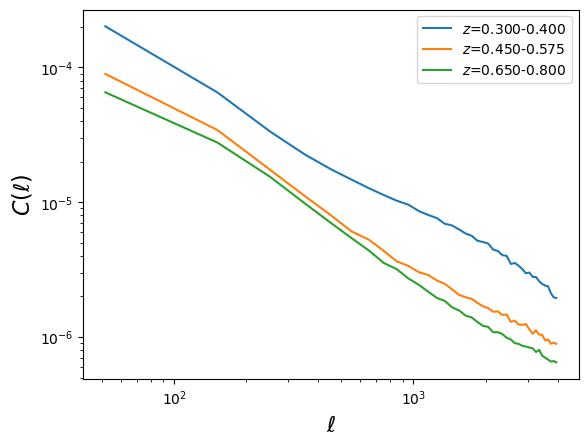

In [5]:
plt.figure()
for jz, zval_group in tqdm(enumerate(zvals)):
    plt.plot(Cl_gg_all['l_array'], Cl_gg_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'], label=fr'$z$={zval_group[0]:.3f}-{zval_group[-1]:.3f}')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$C(\ell)$', fontsize=16)


3it [00:00, 333.58it/s]


Text(0, 0.5, '$n(z)$')

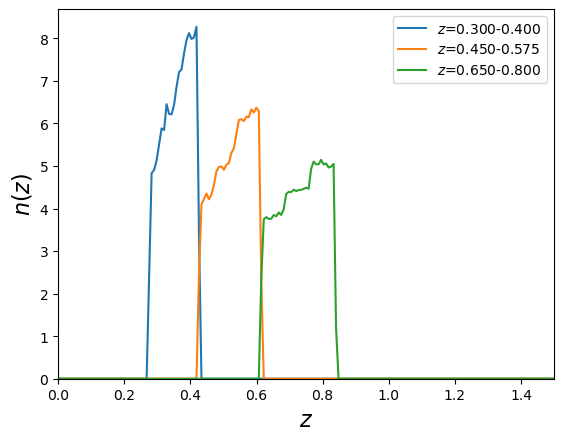

In [6]:
plt.figure()
for jz, zval_group in tqdm(enumerate(zvals)):
    plt.plot(nz_gal_all['z_array'], nz_gal_all[f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}'], label=fr'$z$={zval_group[0]:.3f}-{zval_group[-1]:.3f}')
# plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.ylim(0,)
plt.xlim(0, 1.5)
plt.xlabel(r'$z$', fontsize=16)
plt.ylabel(r'$n(z)$', fontsize=16)




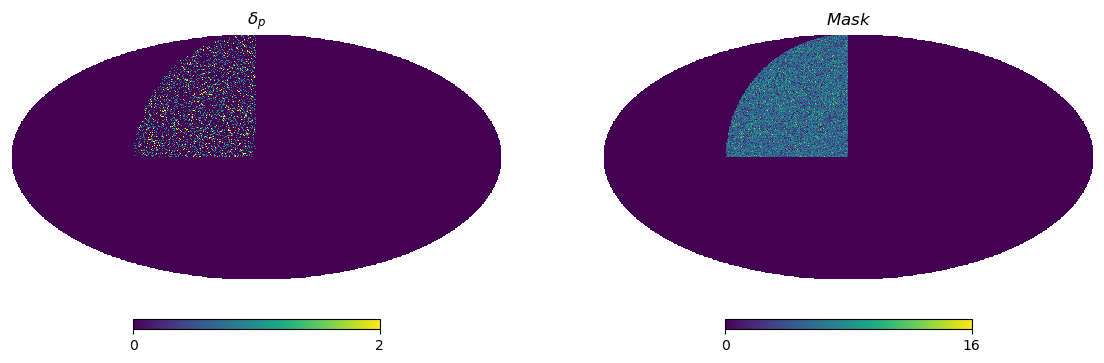

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
plt.axes(axes[0])
hp.mollview(nmap, title=r'$\delta_p$', hold=True, max=2)
plt.axes(axes[1])
hp.mollview(nmap_rand, title='$Mask$', hold=True)



In [ ]:
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)


In [ ]:


nside = 2048

# zvals = [0.3, 0.5, 0.725]
zvals = [0.3, 0.35, 0.4, 0.45, 0.5, 0.575, 0.65, 0.725, 0.8, 0.875, 0.95, 1.025, 1.1]

nz_gal_all = {}
# Cl_gg_all = {}
z_array = np.linspace(0, 1.5, 200)
z_centers = 0.5 * (z_array[1:] + z_array[:-1])
nz_gal_all['z_array_nz'] = z_centers

z_array_comoving np.linspace(0, 1.2, 20)
z_centers_comoving = 0.5 * (z_array_comoving[1:] + z_array_comoving[:-1])
nz_gal_all['z_array_comoving'] = z_centers_comoving

for jz, zval in enumerate(zvals):
    ldir = '/mnt/ceph/users/spandey/abacus/AbacusSummit_base_c000_ph000'
    fn = f"{ldir}/z{zval:.3f}/catalog_DESI_LRG.asdf"
    f = asdf.open(fn)

    gal_ra, gal_dec = f['data']['RA'], f['data']['DEC']
    gal_z = f['data']['Z_COSMO']

    rand_ra, rand_dec = f['data']['RAND_RA'], f['data']['RAND_DEC']
    rand_z = f['data']['RAND_Z']

    hist_z = np.histogram(gal_z, bins=z_array, density=True)[0]
    hist_z_rand = np.histogram(rand_z, bins=z_array, density=True)[0]

    nz_gal_all[f'z{zval:.3f}'] = hist_z

    zmin = np.amin(gal_z)
    zmax = np.amax(gal_z)
    zarray_comoving = np.linspace(zmin, zmax, 6)
    chi_array = radial_comoving_distance(cosmo_jax, 1.0/(1.0 + zarray_comoving))
    chi_min = chi_array[0:-1]
    chi_max = chi_array[1:]

    comoving_volume = (4.0/3.0) * np.pi * (chi_max**3 - chi_min**3) * (1/8.)
    nbar = len(gal_z) / comoving_volume  # in (Mpc/h)^-3
    nbar_all.append(nbar)


    # ipix = hp.ang2pix(nside, gal_ra, gal_dec, lonlat=True)
    # npix = hp.nside2npix(nside)

    # nmap = np.bincount(ipix, minlength=npix)

    # ipix_rand = hp.ang2pix(nside, rand_ra, rand_dec, lonlat=True)
    # npix_rand = hp.nside2npix(nside)

    # nmap_rand = np.bincount(ipix_rand, minlength=npix_rand)

    # lmax = 2*nside
    # b = nmt.NmtBin.from_lmax_linear(lmax, nlb=100)
    # leff = b.get_effective_ells()
    # pos_data = np.array([f['data']['RA'], f['data']['DEC']])
    # w_data = np.ones_like(f['data']['RA'])
    # pos_ran = np.array([f['data']['RAND_RA'], f['data']['RAND_DEC']])
    # w_ran = np.ones_like(f['data']['RAND_RA'])
    # f_cat = nmt.NmtFieldCatalogClustering(pos_data, w_data, pos_ran, w_ran, lmax=lmax, lonlat=True)
    # w_cat = nmt.NmtWorkspace.from_fields(f_cat, f_cat, b)
    # pcl = nmt.compute_coupled_cell(f_cat, f_cat)
    # cl_cat = w_cat.decouple_cell(pcl)

    # Cl_gg_all['l_array'] = leff
    # Cl_gg_all[f'z{zval:.3f}'] = cl_cat[0]



